## Import Libraries

In [1]:
import os
import random
import shutil

import torch 
import torch.nn as nn
import torch.optim as optim

import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm as tqdm

from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from torchinfo import summary

## Device Setup

In [2]:
device = torch.device("cuda" if torch.cuda.is_available else "cpu")
print(device)

cuda


## Dataset Splitting


In [3]:
# dataset_dir = "Cat_Dog_Dataset"
# output_dir = "Cat_Dog_Dataset_70_15_15"
# classes = ["Cat","Dog"]

# train_ratio = 0.7
# val_ratio = 0.15
# test_ratio = 0.15


# #Create folders
# for split in ["train", "val", "test"]:
#     for cls in classes:
#         os.makedirs(os.path.join(output_dir, split,cls), exist_ok=True)


# for cls in classes:
#     class_path = os.path.join(dataset_dir,cls)
#     images = os.listdir(class_path)
#     random.shuffle(images)
#     total = len(images)

#     train_end = int(train_ratio * total)
#     val_end = int((train_ratio + val_ratio)* total)
    
#     train_images = images[:train_end]
#     val_images = images[train_end:val_end]
#     test_images = images[val_end:]

#     for img in train_images:
#         shutil.copy(
#             os.path.join(class_path, img),
#             os.path.join(output_dir,"train", cls, img)
#         )
#     for img in val_images:
#         shutil.copy(
#             os.path.join(class_path, img),
#             os.path.join(output_dir,"val", cls, img)
#         )

#     for img in test_images:
#         shutil.copy(
#             os.path.join(class_path, img),
#             os.path.join(output_dir,"test", cls, img)
#         )
    
# print("Dataset Split Completed!")

## Load Dataset and Image Transformations

In [4]:
transform = transforms.Compose([
    transforms.Resize((128,128)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean = [0.485, 0.456, 0.406],
        std = [0.299, 0.224, 0.255]
    )
])

In [5]:
train_datasets = datasets.ImageFolder(fr"Cat_Dog_Dataset_70_15_15\train", transform= transform)
val_datasets = datasets.ImageFolder(fr"Cat_Dog_Dataset_70_15_15\val", transform= transform)
test_datasets = datasets.ImageFolder(fr"Cat_Dog_Dataset_70_15_15\test", transform= transform)

In [6]:
print(len(train_datasets))
print(len(val_datasets))
print(len(test_datasets))

17494
3750
3752


## DataLoaders

In [7]:
train_loader = DataLoader(train_datasets, batch_size = 8, shuffle=True)
val_loader = DataLoader(val_datasets, batch_size=8)
test_loader = DataLoader(test_datasets, shuffle=True)

## Visualize Dataset Samples

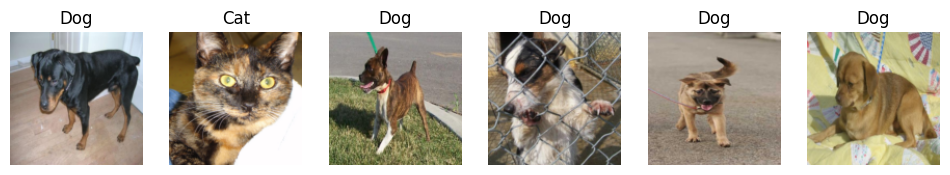

In [8]:
def show_images(loader):
    images, labels = next(iter(loader))
    fig, axes = plt.subplots(1,6, figsize =(12,4))
    class_names = train_datasets.classes
    

    for i in range(6):
        img = images[i].numpy().transpose((1,2,0))
        mean =np.array([0.485, 0.456, 0.406]),
        std = np.array([0.299, 0.224, 0.255]),
        img = std *img + mean
        img = np.clip(img, 0, 1)
        axes[i].imshow(img)
        axes[i].set_title(class_names[labels[i]])
        axes[i].axis("off")
    plt.show()

show_images(train_loader)

## CNN Model

In [9]:
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),

            nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),

            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )

        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64*16*16,128),
            nn.ReLU(),
            nn.Linear(128,2)
        )
    
    def forward(self,x):
        x = self.conv(x)
        x = self.fc(x)
        return x

In [10]:
#Creating Model
model = CNN().to(device)
summary(model, input_size=(8,3,128,128))

Layer (type:depth-idx)                   Output Shape              Param #
CNN                                      [8, 2]                    --
├─Sequential: 1-1                        [8, 64, 16, 16]           --
│    └─Conv2d: 2-1                       [8, 16, 128, 128]         448
│    └─ReLU: 2-2                         [8, 16, 128, 128]         --
│    └─MaxPool2d: 2-3                    [8, 16, 64, 64]           --
│    └─Conv2d: 2-4                       [8, 32, 64, 64]           4,640
│    └─ReLU: 2-5                         [8, 32, 64, 64]           --
│    └─MaxPool2d: 2-6                    [8, 32, 32, 32]           --
│    └─Conv2d: 2-7                       [8, 64, 32, 32]           18,496
│    └─ReLU: 2-8                         [8, 64, 32, 32]           --
│    └─MaxPool2d: 2-9                    [8, 64, 16, 16]           --
├─Sequential: 1-2                        [8, 2]                    --
│    └─Flatten: 2-10                     [8, 16384]                --
│    └─

## Loss Function and Optimizer

In [11]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr = 0.001)

## Training Loop

In [12]:
epochs = 8

train_losses = []
val_losses = []

train_accuracies = []
val_accuracies = []

for epoch in range(epochs):
    model.train()
    running_train_loss = 0.0
    train_loss = 0.0

    correct = 0
    total = 0 

    print(f"Epoch : {epoch+1}/{epochs}")
    train_bar = tqdm(train_loader, desc = f"Training")

    for images, labels in train_bar:

        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()
        
        running_train_loss += loss.item()

        _, preds = torch.max(outputs, 1)
        
        correct += (preds == labels).sum().item()
        total += labels.size(0)

        acc = correct/total

        train_bar.set_postfix(loss = loss.item(), acc = acc)
    
    train_loss = running_train_loss/len(train_loader)
    train_acc = correct/total

    train_losses.append(train_loss)
    train_accuracies.append(train_acc)


    #validation
    model.eval()
    running_val_loss = 0.0
    val_loss = 0.0

    correct = 0
    total = 0

    val_bar = tqdm(val_loader, desc = "Validation")

    with torch.no_grad():
        for images,labels in val_bar:
            images , labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            running_val_loss += loss.item()

            _, preds = torch.max(outputs, 1)
        
            correct += (preds == labels).sum().item()
            total += labels.size(0)

            val_bar.set_postfix(loss = loss.item())
        
        val_loss = running_val_loss/len(val_loader)
        val_acc = correct/ total

        val_losses.append(val_loss)
        val_accuracies.append(val_acc)

        print(f"Train Loss = {train_loss:.4f}  | Train Accuracy = {train_acc:.4f}")  
        print(f"Validation Loss = {val_loss:.4f}  | Validation Accuracy = {val_acc:.4f}")  

Epoch : 1/8


Training: 100%|█████████▉| 2178/2187 [01:43<00:00, 21.05it/s, acc=0.637, loss=1.07] c:\Users\sanje\AppData\Local\Programs\Python\Python313\Lib\site-packages\PIL\TiffImagePlugin.py:949: UserWarning: Truncated File Read
  warnings.warn(str(msg))
Validation: 100%|██████████| 469/469 [00:19<00:00, 24.63it/s, loss=0.397]


Train Loss = 0.6168  | Train Accuracy = 0.6373
Validation Loss = 0.5206  | Validation Accuracy = 0.7323
Epoch : 2/8


Validation: 100%|██████████| 469/469 [00:19<00:00, 24.25it/s, loss=0.404] 


Train Loss = 0.4773  | Train Accuracy = 0.7715
Validation Loss = 0.5065  | Validation Accuracy = 0.7608
Epoch : 3/8


...

Train Loss = 0.1000  | Train Accuracy = 0.9619
Validation Loss = 0.6685  | Validation Accuracy = 0.8077
Epoch : 7/8


Validation: 100%|██████████| 469/469 [00:18<00:00, 25.28it/s, loss=0.22]    


Train Loss = 0.0677  | Train Accuracy = 0.9755
Validation Loss = 0.9900  | Validation Accuracy = 0.8032
Epoch : 8/8


Validation: 100%|██████████| 469/469 [00:18<00:00, 25.05it/s, loss=0.785]   

Train Loss = 0.0493  | Train Accuracy = 0.9833
Validation Loss = 1.0078  | Validation Accuracy = 0.7931


## Save Model

In [13]:
torch.save(model.state_dict(), "CatDogClassifier.pt")

## Loss and Accuracy Curve

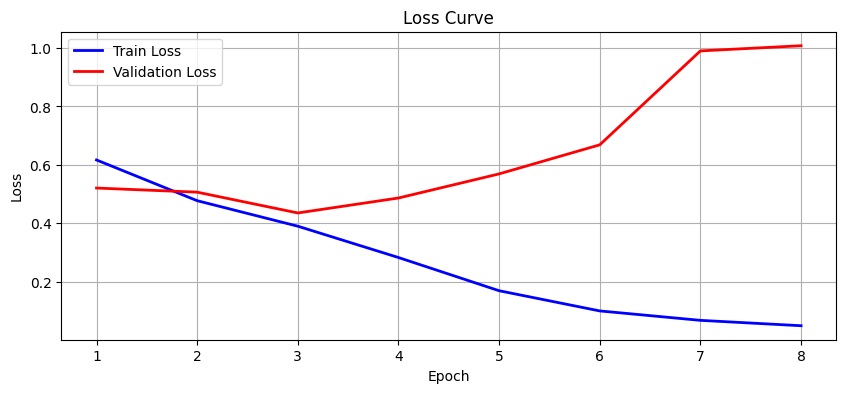

In [14]:
epochs = range(1,len(train_losses)+1)
plt.figure(figsize = (10,4))

#Loss
plt.plot(epochs, train_losses, label ="Train Loss", color ="blue", linewidth = 2)
plt.plot(epochs, val_losses, label = "Validation Loss", color = "red", linewidth = 2)
plt.title("Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

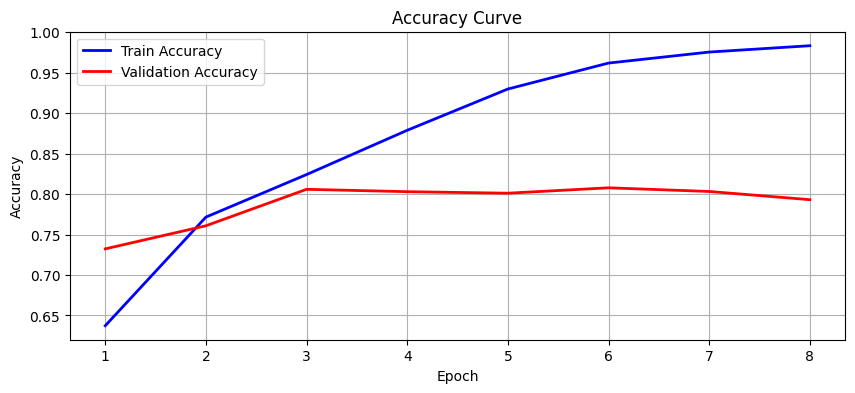

In [15]:
plt.figure(figsize = (10,4))

#Accuracy
plt.plot(epochs, train_accuracies, label ="Train Accuracy", color ="blue", linewidth = 2)
plt.plot(epochs, val_accuracies, label = "Validation Accuracy", color = "red", linewidth = 2)
plt.title("Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

## Evluation

In [ ]:
model = CNN()
model.load_state_dict(torch.load("CatDogClassifier.pt", map_location=device))
model.eval()
model.to(device)

CNN(
  (conv): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=16384, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=2, bias=True)
  )
)

In [18]:
all_preds = []
all_labels = []

with torch.no_grad():
    for images,labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs,1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

In [19]:
all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

accuracy = (all_preds == all_labels).mean() * 100

print("Test Accuracy:", accuracy)

Test Accuracy: 78.89125799573561


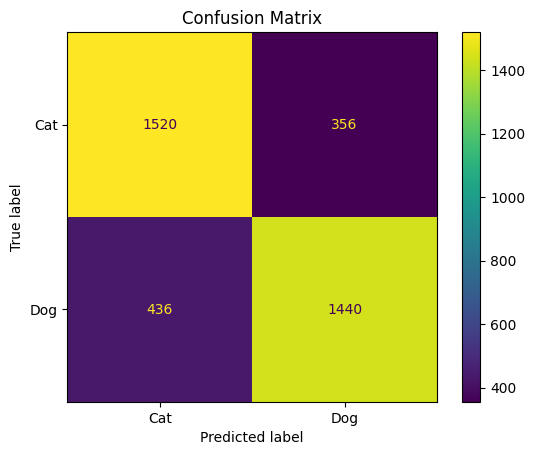

In [20]:
cm = confusion_matrix(all_labels, all_preds)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=test_datasets.classes)

disp.plot()

plt.title("Confusion Matrix")

plt.show()

## Infrence 

In [ ]:
from PIL import Image
import torch.nn.functional as F

def predict_image(image_path, model, transform, class_names):
    img = Image.open(image_path).convert("RGB")

    img_t = transform(img)

    img_t = img_t.unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = model(img_t)

        probs = F.softmax(outputs, dim = 1)

        conf, pred = torch.max(probs, 1)

    predicted_label = class_names[pred.item()]

    confidence = conf.item()*100

    plt.imshow(img)
    plt.title(f"Predicted: {predicted_label}({confidence:.2f}%)")
    plt.axis("off")
    plt.show()

    return predicted_label, confidence

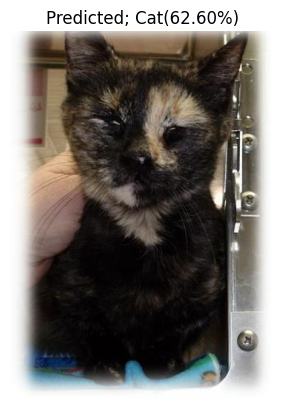

Predicted Label : Cat, Confidence : 62.60


In [32]:
image_path = fr"D:\Cat_Dog_Image_Classification\Cat_Dog_Dataset_70_15_15\test\Cat\1411.jpg"

predicted_label, confidence = predict_image(image_path, model, transform,test_datasets.classes)

print(f"Predicted Label : {predicted_label}, Confidence : {confidence:.2f}")